In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np

plt.style.use('default')
plt.rcParams.update({'font.size': 12})

# torch.set_default_dtype(torch.float64)

from agent.components.commons import ServiceFeatureMapping, ServiceType, FIG_SIZE_4_ROW, FIG_SIZE_3_ROW
from notebooks.create_deepGP import prepare_chained_data, get_prepared_metrics_df, DynamicServiceChain, \
    create_training_data

training_df = get_prepared_metrics_df("../statics/agent_experience/metrics_ICSOC_EXPLORE.csv", offset=0.0, share=0.16)
evaluation_df = get_prepared_metrics_df("../statics/agent_experience/metrics_ICSOC_EXPLORE.csv", offset=0.16, share=0.2)

QR_MAP = ServiceFeatureMapping(ServiceType.QR, [0, 1])
CV_MAP = ServiceFeatureMapping(ServiceType.CV, [2, 3, 4])
PC_MAP = ServiceFeatureMapping(ServiceType.PC, [5, 6])

repetitions = 2
base_chain = [QR_MAP, CV_MAP, PC_MAP]
chain_definition = base_chain  # ([QR_MAP] * repetitions) #+ ([CV_MAP] * repetitions) + ([PC_MAP] * repetitions))

X_final, Y_final, scaler_X = prepare_chained_data(training_df, chain_definition)
train_loader, test_x, test_y = create_training_data(X_final, Y_final, test_size=None)

In [2]:
def get_training_chunks(num_services, granularity):
    if granularity is None:
        return [list(range(num_services))]
    # Create chunks of size 'granularity'
    return [list(range(i, min(i + granularity, num_services)))
            for i in range(0, num_services, granularity)]


In [3]:
def run_training(train_loader, chunks, boundaries, epochs=800):
    model = DynamicServiceChain(chain_definition)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

    mlls = [
        gpytorch.mlls.VariationalELBO(model.likelihoods[i], model.gp_layers[i], num_data=len(train_loader.dataset))
        for i in range(len(chain_definition))
    ]

    model.train()
    for epoch in range(epochs):
        for x_batch, y_batch in train_loader:
            optimizer.zero_grad()

            # 1. Forward pass tells the model where to break the chain
            distributions = model(x_batch, boundary_indices=boundaries)

            # 2. Backward passes for each chunk
            for chunk_indices in chunks:
                # This loss ONLY sees the graph for its specific chunk
                loss = sum([-mlls[i](distributions[i], y_batch[:, i]) for i in chunk_indices])

                # TODO: verify if this makes a difference
                # Since chunks are detached from each other, they don't share paths.
                # You likely don't even need retain_graph=True now!
                loss.backward(retain_graph=True)

            optimizer.step()

        if epoch % 10 == 0:
            print(f"Epoch {epoch} | Loss: {loss.item():.4f}")
        if epoch % 50 == 0:
            for i, likelihood in enumerate(model.likelihoods):
                print(f"Noise: {likelihood.noise.item():.4f}")

    for i, gp_layer in enumerate(model.gp_layers):
        print(gp_layer.covar_module.base_kernel.lengthscale)

    return model


In [4]:
import torch
import gpytorch


def evaluate_model_performance(dgp_model, test_x, test_y, boundaries, num_mc=100):
    """
    Evaluates a Deep GP chain of arbitrary length.

    Args:
        dgp_model: The DynamicServiceChain instance.
        test_x: Test features tensor.
        test_y: Ground truth targets tensor.
        num_mc: Number of Monte Carlo simulations.
    """
    dgp_model.eval()
    all_samples = []
    num_services = len(dgp_model.configs)

    with torch.no_grad(), gpytorch.settings.cholesky_jitter(1e-3):
        for _ in range(num_mc):
            # 1. Dynamically capture all output distributions
            distributions = dgp_model(test_x, boundary_indices=boundaries)

            # 2. Sample from each distribution and stack
            samples = [dist.sample() for dist in distributions]
            s = torch.stack(samples, dim=-1)
            all_samples.append(s)

        # Shape: (num_mc, num_test_samples, num_services)
        combined_samples = torch.stack(all_samples, dim=0).cpu().numpy()

    # --- MODEL VALIDATION ---
    # Get the mean prediction for each service across MC samples
    predicted_means = combined_samples.mean(axis=0)

    # Convert ground truth to numpy
    actual_y = test_y.cpu().numpy()

    print(f"\n--- Model Evaluation ({num_services} Services) ---")

    # 3. Calculate Error dynamically using the names in the model config
    for i, config in enumerate(dgp_model.configs):
        # Use the name or service_type from the config
        # name = config.name if config.name else config.service_type.value

        rmse = np.sqrt(np.mean((predicted_means[:, i] - actual_y[:, i]) ** 2))
        print(f"Stage {i} [{config.service_type.value}] RMSE: {rmse:.4f}")

    return combined_samples

In [5]:
def draw_distribution(combined_samples, chain_definition, test_y):
    # 1. Calculate Mean and Std
    means_per_config = combined_samples.mean(axis=0)
    stds_per_config = combined_samples.std(axis=0)
    global_means = means_per_config.mean(axis=0)
    global_stds = stds_per_config.mean(axis=0)

    # 2. Calculate RMSE per stage
    actual_y = test_y.cpu().numpy()
    rmses = np.sqrt(np.mean((means_per_config - actual_y)**2, axis=0))

    # 3. Setup Plot
    labels = [f"{i+1}: {conf.service_type.name}" for i, conf in enumerate(chain_definition)]
    stages = range(len(labels))
    fig, ax1 = plt.subplots(figsize=FIG_SIZE_3_ROW)

    # --- PRIMARY AXIS: Throughput (BLACK) ---
    # Using black for the line and dark gray for error bars to keep it clean
    line1 = ax1.errorbar(stages, global_means, yerr=global_stds, fmt='-s', capsize=10,
                         color='black', ecolor='dimgray', elinewidth=2, markersize=8,
                         label='Mean / Std')

    ax1.set_ylabel("Relative Throughput (0 to 1)", color='black')
    ax1.set_xlabel("Service Pipeline Sequence")
    ax1.tick_params(axis='y', labelcolor='black')

    # --- SECONDARY AXIS: RMSE (ORANGE) ---
    ax2 = ax1.twinx()
    line2 = ax2.plot(stages, rmses, '-o', color='darkorange', markersize=6,
                     label='RMSE', linestyle='--')
    ax2.set_ylabel("RMSE (Prediction Error)", color='darkorange')
    ax2.tick_params(axis='y', labelcolor='darkorange')

    # Dynamic limit for RMSE to keep the trend visible
    ax2.set_ylim(0, max(rmses) * 1.5 if len(rmses) > 0 else 1)

    # 4. Formatting
    ax1.set_xticks(stages)
    ax1.set_xticklabels(labels, rotation=45, ha='right')
    ax1.grid(axis='y', alpha=0.2)

    # Combined Legend
    lines = [line1] + line2
    labels_legend = [l.get_label() for l in lines]
    ax1.legend(lines, labels_legend, loc='upper right')

    plt.tight_layout()

    # Save logic
    service_concat_string = "_".join([conf.service_type.name for conf in chain_definition])
    # Using bbox_inches='tight' ensures the rotated labels and legend are fully captured
    plt.savefig(f"../figures/E2/expectation_{service_concat_string}.pdf", bbox_inches='tight')
    plt.show()

In [6]:
dgp_granularity = 1
retrain_base_DGP = True

# Example: granularity=2, num_services=6
# chunks = [[0, 1], [2, 3], [4, 5]]
# boundaries = [2, 4] (Indices where we cut the gradient)
chunks = get_training_chunks(len(chain_definition), dgp_granularity)
boundaries_single = [chunk[0] for chunk in chunks if chunk[0] != 0]

if retrain_base_DGP:
    print(f"Starting training with granularity={dgp_granularity}. Chunks: {chunks}")
    model_single = run_training(train_loader, chunks, boundaries_single, epochs=210)
    torch.save(model_single.state_dict(), 'service_chain_model_single.pth')
else:
    # 2. Instantiate the model class with the configuration
    model_single = DynamicServiceChain(service_configs=chain_definition)
    state_dict = torch.load('service_chain_model_single.pth')
    model_single.load_state_dict(state_dict)

    model_single.eval()
    print("Model loaded successfully!")

Starting training with granularity=1. Chunks: [[0], [1], [2]]


/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 0 | Loss: 1.2696
Noise: 0.7032
Noise: 0.7030
Noise: 0.7027
Epoch 10 | Loss: 0.8124
Epoch 20 | Loss: 0.6643
Epoch 30 | Loss: 0.5604
Epoch 40 | Loss: 0.4769
Epoch 50 | Loss: 0.3675
Noise: 0.2970
Noise: 0.2674
Noise: 0.2757
Epoch 60 | Loss: 0.2832
Epoch 70 | Loss: 0.2182
Epoch 80 | Loss: 0.0983
Epoch 90 | Loss: 0.0055
Epoch 100 | Loss: -0.1106
Noise: 0.1016
Noise: 0.0933
Noise: 0.0997
Epoch 110 | Loss: -0.1762
Epoch 120 | Loss: -0.2612
Epoch 130 | Loss: -0.3637
Epoch 140 | Loss: -0.3434
Epoch 150 | Loss: -0.5460
Noise: 0.0344
Noise: 0.0353
Noise: 0.0386
Epoch 160 | Loss: -0.5570
Epoch 170 | Loss: -0.4545
Epoch 180 | Loss: -0.5282
Epoch 190 | Loss: -0.4953
Epoch 200 | Loss: -0.8104
Noise: 0.0120
Noise: 0.0169
Noise: 0.0187
tensor([[1.3138, 1.5423]], grad_fn=<SoftplusBackward0>)
tensor([[1.1865, 2.0759, 1.8889, 1.4401]], grad_fn=<SoftplusBackward0>)
tensor([[2.0746, 1.8396, 1.0078]], grad_fn=<SoftplusBackward0>)



--- Model Evaluation (3 Services) ---
Stage 0 [elastic-workbench-qr-detector] RMSE: 0.0232
Stage 1 [elastic-workbench-cv-analyzer] RMSE: 0.0842
Stage 2 [elastic-workbench-pc-visualizer] RMSE: 0.0868


/tmp/ipykernel_31489/3254904313.py:29: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  line2 = ax2.plot(stages, rmses, '-o', color='darkorange', markersize=6,


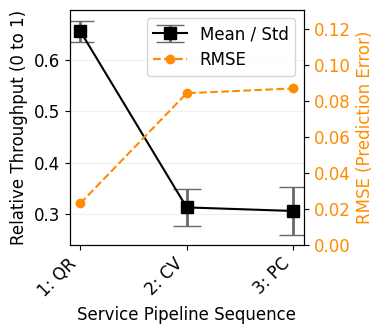

In [7]:
# train_loader, test_x, test_y, scaler_X = prepare_chained_data(converted_df, chain_definition, test_size=0.2)

# combined_samples_global = evaluate_model_performance(model_global, test_x, test_y, boundaries_global, 100)
# draw_distribution(combined_samples_global, chain_definition)

combined_samples_single = evaluate_model_performance(model_single, test_x, test_y, boundaries_single, 100)
draw_distribution(combined_samples_single, chain_definition, test_y)

In [8]:
# def plot_residual_divergence(samples_none, samples_one, test_y):
#     # Calculate Error (Predicted Mean - Actual)
#     err_none = np.abs(samples_none.mean(axis=0) - test_y.cpu().numpy())
#     err_one = np.abs(samples_one.mean(axis=0) - test_y.cpu().numpy())
#
#     plt.figure(figsize=(10, 5))
#     plt.plot(err_none.mean(axis=0), label='Global Error', color='blue', marker='o')
#     plt.plot(err_one.mean(axis=0), label='Independent Error', color='green', marker='x')
#
#     plt.title("Error Propagation: Global vs Independent")
#     plt.xlabel("Chain Stage")
#     plt.ylabel("Mean Absolute Error")
#     plt.legend()
#     plt.show()
#
# plot_residual_divergence(combined_samples_global, combined_samples_single, test_y)

In [9]:
import torch
import copy


def expand_selected_services(model_single: DynamicServiceChain, composite_model: DynamicServiceChain):
    """
    Knowledge Transfer from [QR, CV, PC] to [QR, CV, CV, PC, PC].
    - QR (Stage 0): Direct Copy (2D)
    - CV (Stage 1): Direct Copy (3D - already 3D in model_single)
    - CV (Stage 2): Mirror Injection (3D -> 3D)
    - PC (Stage 3): Direct Copy (3D)
    - PC (Stage 4): Mirror Injection (3D -> 3D)
    """

    # Mapping the target indices to the expert indices in model_single
    # Target: 0 (QR), 1 (CV), 2 (CV), 3 (PC), 4 (PC)
    # Source: 0 (QR), 1 (CV), 1 (CV), 2 (PC), 2 (PC)
    service_to_index = {ServiceType.QR: 0, ServiceType.CV: 1, ServiceType.PC: 2}
    mapping = [service_to_index[s_map.service_type] for s_map in composite_model.configs]

    with torch.no_grad():
        for i, src_idx in enumerate(mapping):
            expert_gp = model_single.gp_layers[src_idx]
            target_gp = composite_model.gp_layers[i]

            # Case 1: Shapes match (Direct weight transfer)
            # This happens for Stage 0 (QR) and the first instances of CV and PC
            if expert_gp.variational_strategy.inducing_points.shape == target_gp.variational_strategy.inducing_points.shape:
                target_gp.load_state_dict(copy.deepcopy(expert_gp.state_dict()))
                composite_model.likelihoods[i].load_state_dict(
                    copy.deepcopy(model_single.likelihoods[src_idx].state_dict()))

            # Case 2: Size Mismatch (Injection needed)
            # This would happen if you were moving a 2D expert into a 3D slot
            else:
                # raise RuntimeError("I should avoid this scenario")
                expert_state = expert_gp.state_dict()
                target_state = target_gp.state_dict()

                for name, param in expert_state.items():
                    # SKIP constraint bounds: they cause size mismatches and aren't learnable anyway
                    if 'constraint.lower_bound' in name or 'constraint.upper_bound' in name:
                        continue

                    if 'inducing_points' in name:
                        col_to_inject = param[:, 0:1]
                        target_state[name] = torch.cat([param, col_to_inject], dim=1)

                    elif 'raw_lengthscale' in name:
                        # Get the expected number of dims from the target model
                        target_dims = target_gp.covar_module.base_kernel.ard_num_dims

                        if param.dim() == 0:
                            # Scalar -> Vector [3]
                            target_state[name] = param.unsqueeze(0).repeat(target_dims)
                        elif param.dim() == 1:
                            # Vector [2] -> Vector [3]
                            val_to_inject = param[0:1]
                            target_state[name] = torch.cat([param, val_to_inject], dim=0)
                        elif param.dim() == 2:
                            # Matrix [1, 2] -> Matrix [1, 3]
                            val_to_inject = param[:, 0:1]
                            target_state[name] = torch.cat([param, val_to_inject], dim=1)
                    else:
                        target_state[name] = param

                target_gp.load_state_dict(target_state)
                composite_model.likelihoods[i].load_state_dict(
                    copy.deepcopy(model_single.likelihoods[src_idx].state_dict()))



In [10]:
def evaluate_arbitrary_chain(amplified_chain):
    composite_model = DynamicServiceChain(amplified_chain)
    expand_selected_services(model_single, composite_model)

    X_final_comp, Y_final_comp, _ = prepare_chained_data(evaluation_df, amplified_chain)

    X_final_comp = torch.tensor(X_final_comp, dtype=torch.float32)
    Y_final_comp = torch.tensor(Y_final_comp, dtype=torch.float32)

    # TODO: But that's some nonsense, because if I build X services using the data, I cannot give each of them random data, but they must have it from the same 25 samples from the exact same config. Actually, at the same time I can only use the data within one experimental setup

    combined_samples_composite = evaluate_model_performance(composite_model, X_final_comp, Y_final_comp,
                                                            boundaries_single, 100)
    draw_distribution(combined_samples_composite, amplified_chain, Y_final_comp)


--- Model Evaluation (6 Services) ---
Stage 0 [elastic-workbench-qr-detector] RMSE: 0.0270
Stage 1 [elastic-workbench-qr-detector] RMSE: 0.2603
Stage 2 [elastic-workbench-qr-detector] RMSE: 0.3024
Stage 3 [elastic-workbench-qr-detector] RMSE: 0.3159
Stage 4 [elastic-workbench-qr-detector] RMSE: 0.3608
Stage 5 [elastic-workbench-qr-detector] RMSE: 0.3717


/tmp/ipykernel_31489/3254904313.py:29: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  line2 = ax2.plot(stages, rmses, '-o', color='darkorange', markersize=6,


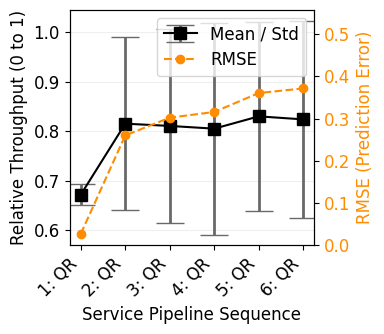

In [11]:
chain_QR_3 = [QR_MAP, QR_MAP, QR_MAP]
# evaluate_arbitrary_chain(chain_QR_3)
evaluate_arbitrary_chain((chain_QR_3 * 2))

In [12]:
# chain_QR_3 = [QR_MAP, QR_MAP, QR_MAP]
# evaluate_arbitrary_chain((chain_QR_3 * 3))


--- Model Evaluation (6 Services) ---
Stage 0 [elastic-workbench-qr-detector] RMSE: 0.0276
Stage 1 [elastic-workbench-cv-analyzer] RMSE: 0.1351
Stage 2 [elastic-workbench-cv-analyzer] RMSE: 0.1977
Stage 3 [elastic-workbench-cv-analyzer] RMSE: 0.2198
Stage 4 [elastic-workbench-cv-analyzer] RMSE: 0.2378
Stage 5 [elastic-workbench-cv-analyzer] RMSE: 0.2350


/tmp/ipykernel_31489/3254904313.py:29: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  line2 = ax2.plot(stages, rmses, '-o', color='darkorange', markersize=6,


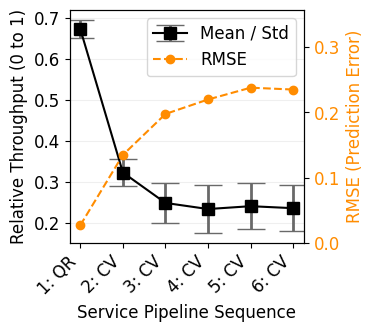

In [13]:
chain_QR_3 = [QR_MAP, QR_MAP, QR_MAP]
evaluate_arbitrary_chain([QR_MAP, CV_MAP, CV_MAP, CV_MAP, CV_MAP, CV_MAP])


--- Model Evaluation (3 Services) ---
Stage 0 [elastic-workbench-qr-detector] RMSE: 0.0285
Stage 1 [elastic-workbench-cv-analyzer] RMSE: 0.1367
Stage 2 [elastic-workbench-pc-visualizer] RMSE: 0.1425


/tmp/ipykernel_31489/3254904313.py:29: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  line2 = ax2.plot(stages, rmses, '-o', color='darkorange', markersize=6,


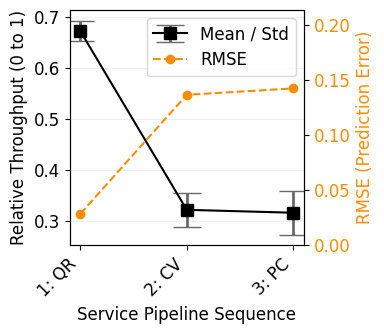

In [14]:
# chain_QR_3 = [QR_MAP, QR_MAP, QR_MAP]
evaluate_arbitrary_chain(base_chain)